<a href="https://colab.research.google.com/github/juanfran18gc-code/jfMIAAD/blob/12-Semana/Practica24_261554.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Maestría en Inteligencia Artificial y Analítica de Datos

## Programación para Analítica Descriptiva y Predictiva - Octubre 2025
## Práctica: Práctica: Regresión Lineal Múltiple
---


## Datos del Estudiante

*   Apellidos y Nombre: Gámez Cortés Juan Francisco
*   Matrícula: 261554

---



##  Objetivo de aprendizaje
Al finalizar esta práctica, el estudiante será capaz de **aplicar regresión lineal múltiple utilizando Scikit-Learn para modelar la relación entre varias variables independientes y una variable dependiente**, verificar los supuestos del modelo, interpretar los coeficientes, analizar la correlación entre predictores y evaluar el rendimiento del modelo utilizando métricas como el MSE, RMSE y R².

Datos
Trabajarás con el archivo `advertising.csv`, que contiene información sobre el gasto publicitario en diferentes medios y las ventas obtenidas:

-`TV`: inversión en publicidad televisiva.

-`Radio`: inversión en publicidad en radio.

-`Newspaper`: inversión en publicidad en periódicos.

`Sales`: ventas del producto (variable dependiente).

## Parte 1: Carga de datos y bibliotecas
1. Importa las bibliotecas necesarias.
2. Carga el archivo `advertising.csv`.
3. Muestra las primeras filas del dataframe.
4. Describe estadísticamente las variables.

In [128]:
# Montar google drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from scipy import stats
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [130]:
# Cargar dataset y analizar
df = pd.read_csv('/content/drive/MyDrive/Unidad03/advertising.csv')
#df['Sales'] = df.target

print(df.info())
print("\n")
print(df.head())
print("\n")
print(df.describe())
print("\n")
# Comprobamos si hay valores nulos
print("\nComprobando valores nulos:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None


      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9


               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.52

## Parte 2: Análisis exploratorio de los datos
### 2.1  Análisis de la Relación Lineal entre la variable dependiente y las independientes
1. Grafica dispersión entre cada variable independiente (`TV`, `Radio`, `Newspaper`) y `Sales`. Usa también regplot.
2. Interpreta visualmente la relación entre variables.

De los gráficos de dispersión podemos obserbar que TV y Sales tienen la relación más clara, al aumentar TV tiende a incremetar Sales de manera consistente. Por otra parte en Newspaper y Sales las observaciones son más dispersas lo que indica una correlación baja.

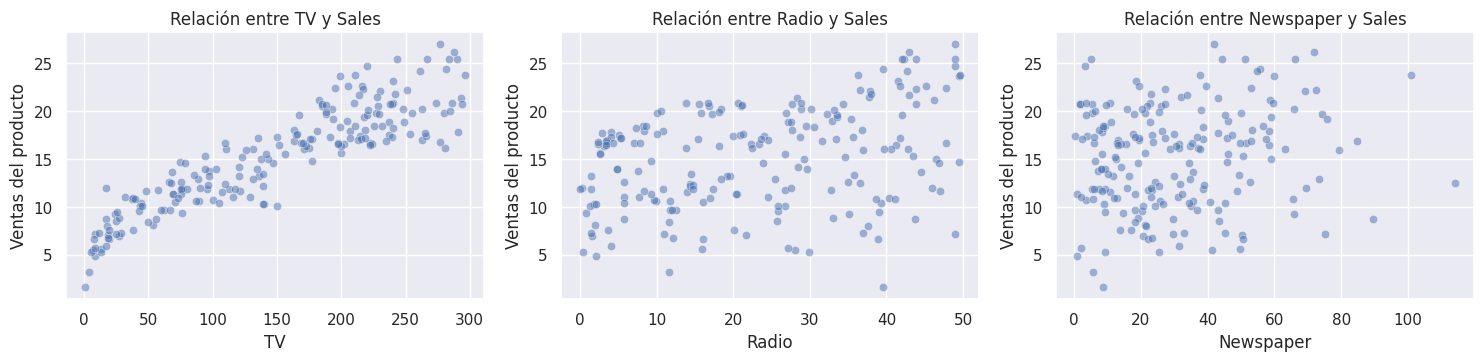

In [131]:
# Visualización de scatterplots entre todas las características y la variable objetivo 'Sales'
plt.figure(figsize=(15, 10))
for i, column in enumerate(df.columns[:-1]):  # Excluimos la columna 'Sales'
    plt.subplot(3, 3, i+1)
    sns.scatterplot(x=df[column], y=df['Sales'], alpha=0.5)
    plt.title(f"Relación entre {column} y Sales")
    plt.xlabel(column)
    plt.ylabel("Ventas del producto")

plt.tight_layout()
plt.show()


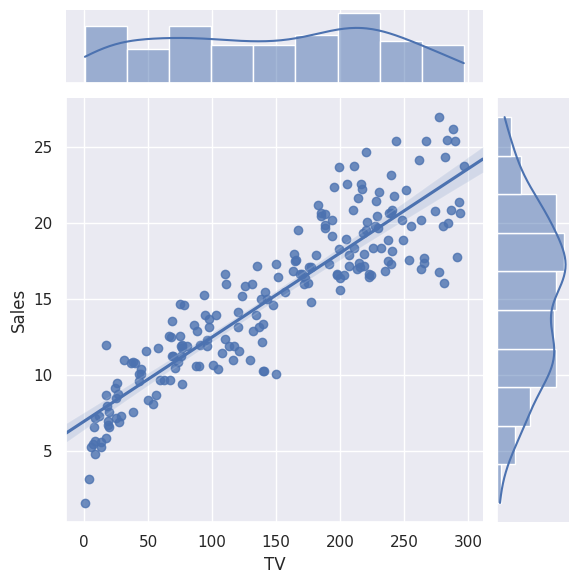

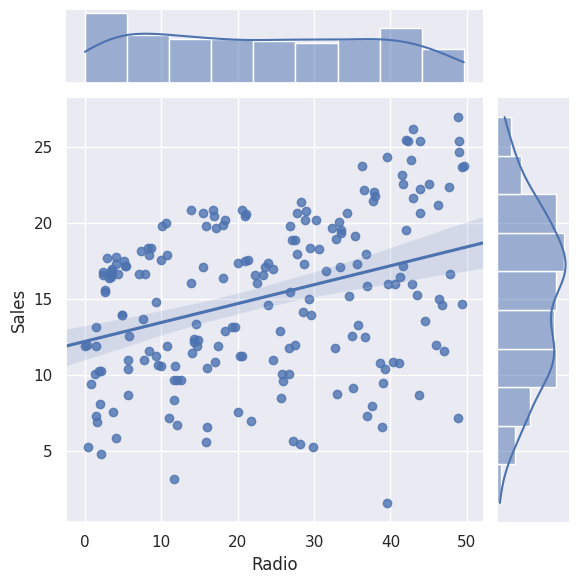

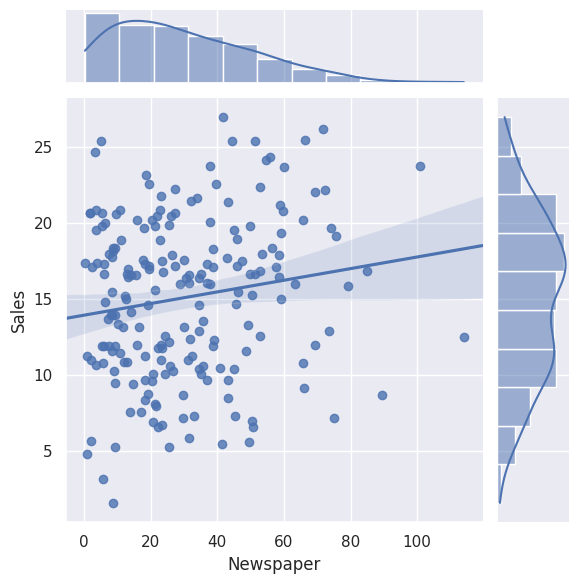

In [132]:
# Grafico joinplot con Regresión
sns.set_theme(style="darkgrid")

for i, column in enumerate(df.columns[:-1]):  # Excluimos la columna 'Sales'
    sns.jointplot(x=df[column], y=df['Sales'], data=df,
                  kind="reg", truncate=False,
                  color="b", height=6)


### 2.2: Correlación entre variables
1. Calcula la matriz de correlación.
2. Visualízala con un heatmap.
3. Responde: ¿Qué variables están más correlacionadas con `Sales`?

La variable con mayor correlación con Sales es TV con 0.90, por su parte Radio tiene una correlación moderada con 0.35


¿Hay correlación alta entre predictores?

Sí, tanto con TV como con Radio pero en menor medida


Matriz de correlación:
                  TV     Radio  Newspaper     Sales
TV         1.000000  0.054809   0.056648  0.901208
Radio      0.054809  1.000000   0.354104  0.349631
Newspaper  0.056648  0.354104   1.000000  0.157960
Sales      0.901208  0.349631   0.157960  1.000000


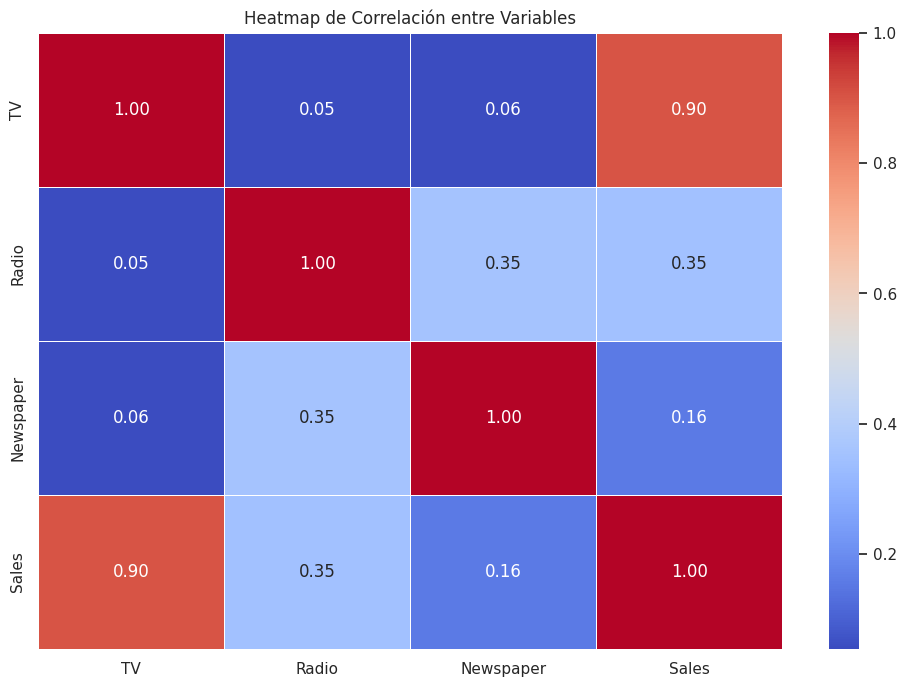

In [133]:
# Correlación y heatmap de correlación entre todas las variables
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()
print("Matriz de correlación:\n",df.corr())
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=True, linewidths=0.5)
plt.title("Heatmap de Correlación entre Variables")
plt.show()

## Parte 3. Multicolinealidad
1. Calcula el VIF (Variance Inflation Factor) para cada predictor.
2. Crea un diagrama de barras  para mostrar el  VIF
3. Interpreta si hay multicolinealidad:
- ¿Alguna variable tiene un VIF mayor a 5 o mayor a 10?

No
- ¿Qué implicaciones tiene esto para el modelo?

Tenemos variables con VIF < 5 por lo cual podemos decir que tenemos una correlación de baja a moderada entre los predictores, lo cual nos permitirá tener coeficientes del modelo estables para predecir


### Análisis de Multicolinealidad ###
    Variable       VIF
0      const  6.848900
1         TV  1.004611
2      Radio  1.144952
3  Newspaper  1.145187


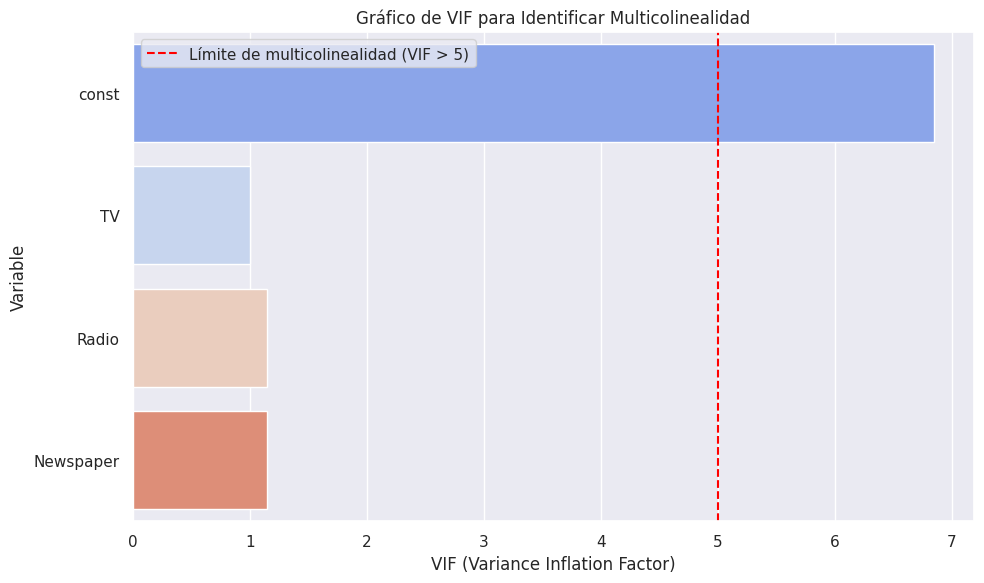

In [134]:
# Multicolinealidad: Cálculo de VIF (Variance Inflation Factor)
# El VIF evalúa la colinealidad de cada variable con respecto a las demás. VIF > 5 o 10 indica posible multicolinealidad.

# Agregar constante para calcular el VIF
X_VIF = add_constant(df.drop(columns=['Sales']))  # Matriz de características sin la variable dependiente
vif_data = pd.DataFrame()
vif_data['Variable'] = X_VIF.columns
vif_data['VIF'] = [variance_inflation_factor(X_VIF.values, i) for i in range(X_VIF.shape[1])]

print("\n### Análisis de Multicolinealidad ###")
print(vif_data)

# Visualización de VIF
plt.figure(figsize=(10, 6))
sns.barplot(x='VIF', y='Variable', data=vif_data, hue='Variable' ,palette='coolwarm', legend=False)
plt.axvline(x=5, color='red', linestyle='--', label='Límite de multicolinealidad (VIF > 5)')
plt.xlabel('VIF (Variance Inflation Factor)')
plt.title('Gráfico de VIF para Identificar Multicolinealidad')
plt.legend()
plt.tight_layout()
plt.show()

## Parte 4: Construcción del Modelo (Todas las variables Independientes), Evaluación

### 4.1 Entrenamiento del Modelo (Todas las Variables Independientes)

1. Entrena un modelo de regresión lineal múltiple usando TV, Radio y Newspaper como variables independientes.
2. Imprime el intercepto y los coeficientes del modelo.
3. Interpreta cada uno:


¿Qué significa cada uno de los coeficientes  en términos de ventas?

*  **Término independiente (intercepto): 15.130500000000001**:
   - Este es el valor de **Sales** cuando todas las variables independientes son igual a 0. Es decir, el valor base de ventas cuando las demás características son iguales a cero..

*  **Coeficiente de TV: 4.662700245086694**:
   - Este coeficiente indica que, si **TV** aumenta en una unidad, el valor de las ventas (**Sales**) aumenta en promedio en 4.66 unidades, manteniendo las demás variables constantes.
   - En términos sencillos, a mayor  inversión en publicidad televisiva (TV), el valor de ventas tiende a ser más alto.

*  **Coeficiente de Radio: 1.5846502733236385**:
   - Este coeficiente indica que, si **Radio** aumenta en una unidad, el valor de las ventas (**Sales**) aumenta en promedio en 1.58 unidades, manteniendo las demás variables constantes.
   - Es decir, a mayor  inversión en publicidad en radio (Radio), el valor de ventas tiende a ser un poco más alto.

*  **Coeficiente de Newspaper: 0.0072918683037688226**:
   - Este coeficiente indica que, si **Newspaper** aumenta en una unidad, el valor de las ventas (**Sales**) aumenta en promedio en 0.007 unidades, manteniendo las demás variables constantes.
   - Es decir, a mayor  inversión en publicidad en periodicos (Newspaper), lo cual indica que el impacto de su incremento es muy bajo.

In [135]:
# Definir las Variables Independientes y Dependientes
X = df.drop(columns='Sales')  # Características
y = df['Sales']  # Variable dependiente (ventas)

In [136]:
# Ajustar el Modelo de Regresión Lineal
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Entrenamiento del Modelo (Todas las Variables Independientes)
model = LinearRegression()
model.fit(X_scaled,y)



LinearRegression()

In [137]:
#Obtener los Coeficientes y el Término Independiente:
coefficients = model.coef_
intercept = model.intercept_

print(f"\nCoeficientes estimados: {coefficients}")
print(f"Término independiente estimado (intercepto): {intercept}")
#######################################################
print('\n')
equation = f"Sales = {intercept} "
for i, coef in enumerate(coefficients):
  equation += f"+ ({coef} * {X.columns[i]}) "

equation #se obtiene el modelo con los coeficientes


Coeficientes estimados: [4.66270025 1.58465027 0.00729187]
Término independiente estimado (intercepto): 15.130500000000001




'Sales = 15.130500000000001 + (4.662700245086694 * TV) + (1.5846502733236385 * Radio) + (0.0072918683037688226 * Newspaper) '

### 4.2 Normalidad de los residuos

1. Calcula los residuos: residuos = y - y_pred.

2. Grafica un histograma con KDE de los residuos.

3. ¿Los residuos parecen distribuirse normalmente?

Sí, en el grafico se puede observar la campaña de gauss que indica una distribución similar a la normal, aunque se presenta una cola larga a la izquierda

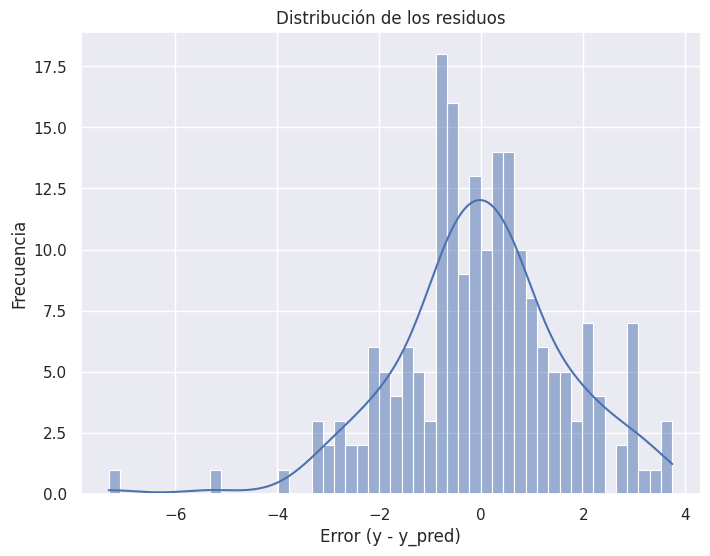

In [138]:
#Normalidad de los residuos

# Realizar predicciones con el modelo
y_pred = model.predict(X_scaled)

# Calcular los residuos del modelo
residuos = y - y_pred

# Histograma de residuos
plt.figure(figsize=(8, 6))
sns.histplot(residuos, bins=50, kde=True)
plt.xlabel("Error (y - y_pred)")
plt.ylabel("Frecuencia")
plt.title("Distribución de los residuos")
plt.show()

### 4.3. Homocedasticidad

1. Grafica los residuos contra los valores predichos.
2. ¿Observas patrones? ¿Los residuos se dispersan aleatoriamente?

No se observan patrones, así mismo, los residuos se dispersan aleatoriamente y existe Homocedasticidad

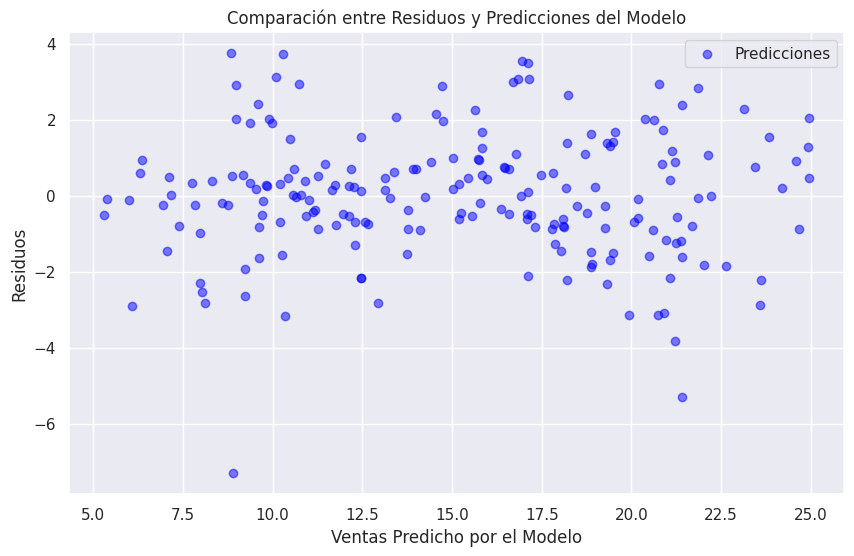


Comparación entre las predicciones y los residuos:
   Residuos  Predicción
0  0.879028   21.220972
1 -0.868248   11.268248
2  1.503791   10.496209
3 -0.812447   17.312447
4  2.255863   15.644137


In [139]:
# Homocedasticidad
# Graficar los residuos frente a las predicciones
plt.figure(figsize=(10, 6))

# Graficar los residuos vs las predicciones
plt.scatter(y_pred, residuos, alpha=0.5, color='blue', label='Predicciones')

# Añadir título y etiquetas
plt.title("Comparación entre Residuos y Predicciones del Modelo")
plt.xlabel("Ventas Predicho por el Modelo")
plt.ylabel("Residuos")

# Añadir leyenda
plt.legend()

# Mostrar la gráfica
plt.show()

# Comparar los primeros valores reales con las predicciones
comparison_residuos = pd.DataFrame({
    'Residuos': residuos.head(),
    'Predicción': y_pred[:5]  # Primeras 5 predicciones
})

print("\nComparación entre las predicciones y los residuos:")
print(comparison_residuos)


### 4.4 Q-Q Plot

1. Graficar el Q-Q Plot
2. Interpreta el gráfico: a) Si los puntos se alinean aproximadamente sobre la línea diagonal, los residuos siguen una distribución normal, b) Desviaciones sistemáticas indican asimetría o colas pesadas.

Los residuos se alinean a la diagonal, por lo cual tenemos una distribución normal, aunque en los extremos observamos algunos puntos alejados a la diagonal lo cual indica la presencia de colas en los extremos

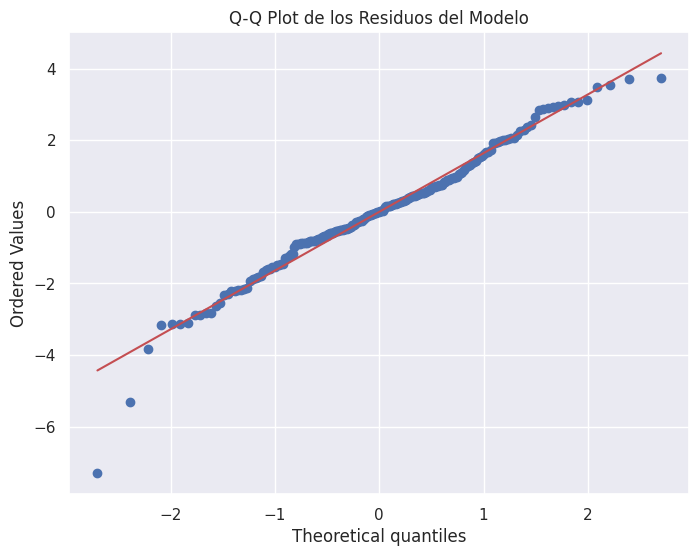

In [140]:
#Q-Q Plot

#  Graficar el Q-Q Plot
plt.figure(figsize=(8, 6))
stats.probplot(residuos, dist="norm", plot=plt)

# Añadir título
plt.title("Q-Q Plot de los Residuos del Modelo")

# Mostrar la gráfica
plt.show()


### 4.5. Evaluación del Modelo

1. Calcula las métricas: a) MSE (error cuadrático medio), b) RMSE (raíz del error cuadrático medio), c) R² (coeficiente de determinación)

2. ¿Qué nos dicen estas métricas sobre el ajuste del modelo?

*  **Error Cuadrático Medio (MSE): 2.7060**  
   El promedio de los errores al cuadrado entre los valores predichos y los valores reales nos emite un valor de **2.7060** indica que el modelo tiene un error moderado.

*  **Raíz del Error Cuadrático Medio (RMSE): 1.6450**  
   La RMSE es una métrica que se encuentra en las mismas unidades que la variable dependiente. Un **RMSE de 1.6450** sugiere que, en promedio, las predicciones del modelo están a aproximadamente **1.6450** de los valores reales. Esto también indica que hay una diferencia moderada entre las predicciones y los valores observados.

*  **Error Absoluto Medio (MAE): 1.2364**  
   Mide el error medio absoluto entre las predicciones y los valores reales. Un valor de **1.2364** muestra que, en promedio, las predicciones del modelo difieren de los valores reales en aproximadamente **1.2364 unidades**, lo que refleja un error moderado. El MAE es menos sensible a outliers que el RMSE.

*  **Coeficiente de Determinación (R²): 0.9026**  
   El R² mide la proporción de la varianza en la variable dependiente que es explicada por el modelo. Un **R² de 0.9026** indica que el modelo explica aproximadamente el **90.26% de la variabilidad** en los datos. Esto sugiere un **ajuste muy bueno**.

In [141]:
#Evaluación del Modelo
# Calcular las métricas del modelo
mse = mean_squared_error(y, y_pred)  # Error cuadrático medio
rmse = np.sqrt(mse)  # Raíz del error cuadrático medio
mae = mean_absolute_error(y, y_pred)  # Error absoluto medio
r2 = r2_score(y, y_pred)  # Coeficiente de determinación R^2

# Mostrar las métricas
print(f"Error Cuadrático Medio (MSE): {mse:.4f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.4f}")
print(f"Error Absoluto Medio (MAE): {mae:.4f}")
print(f"Coeficiente de Determinación (R²): {r2:.4f}")


Error Cuadrático Medio (MSE): 2.7060
Raíz del Error Cuadrático Medio (RMSE): 1.6450
Error Absoluto Medio (MAE): 1.2364
Coeficiente de Determinación (R²): 0.9026


### 4.6. Visualización de Predicciones

1. Crea un gráfico comparando Sales reales vs Sales predichas.

2. Puedes usar plt.scatter(y_true, y_pred) para evaluar visualmente el ajuste.
3.¿Qué observas?¿Qué información puedes obtener de esta gráfica?

Podemos observar que los valores predichos por el modelo son muy cercanos a la línea de perfección, lo cual nos indica que el modelo se genera predicciones precisas y agrupadas, en algunos casos tocan la línea de perfección.  


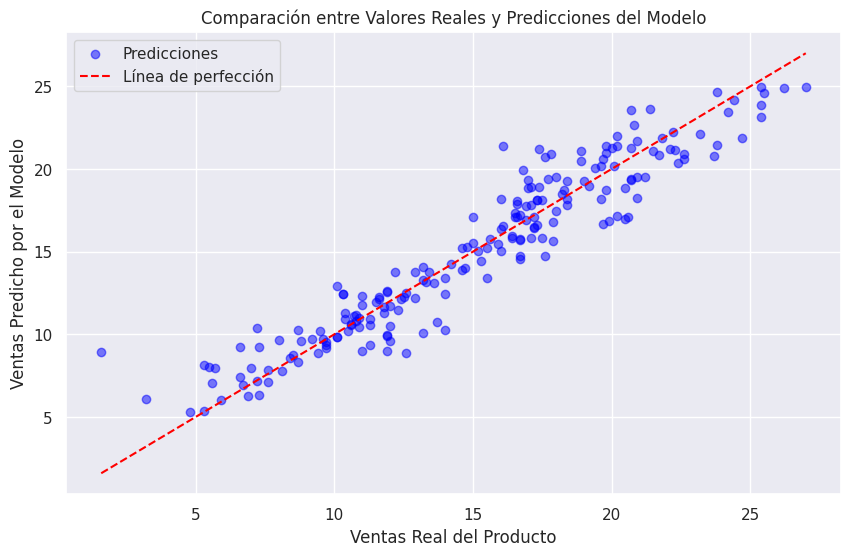


Comparación entre las predicciones y los valores reales:
   Valor Real  Predicción
0        22.1   21.220972
1        10.4   11.268248
2        12.0   10.496209
3        16.5   17.312447
4        17.9   15.644137


In [142]:
# #Visualización de las Predicciones
# Graficar los valores reales frente a las predicciones
plt.figure(figsize=(10, 6))

# Graficar los valores reales vs las predicciones
plt.scatter(y, y_pred, alpha=0.5, color='blue', label='Predicciones')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', label='Línea de perfección')

# Añadir título y etiquetas
plt.title("Comparación entre Valores Reales y Predicciones del Modelo")
plt.xlabel("Ventas Real del Producto")
plt.ylabel("Ventas Predicho por el Modelo")

# Añadir leyenda
plt.legend()

# Mostrar la gráfica
plt.show()

# Comparar los primeros valores reales con las predicciones
comparison = pd.DataFrame({
    'Valor Real': y.head(),
    'Predicción': y_pred[:5]  # Primeras 5 predicciones
})

print("\nComparación entre las predicciones y los valores reales:")
print(comparison)


### 4.7 Verificar el impacto de los atributos en el modelo

1. Ajusta el modelo usando statsmodels en lugar de scikit-learn para obtener los valores p.
2. Interpreta los resultados:

 - Observa los valores P>|t| en la tabla de salida.

 - ¿Qué variables tienen p-value menores a 0.05?

 Las variables TV y Radio tienen valores menores a 0.05

 - ¿Cuál es la conclusión sobre esas variables?

 Las variables TV y Radio son significativas para el modelo predictivo



In [143]:
# Calculo del P-Value para verificar el impacto de los atributos

# Agregar una constante al conjunto de datos X_scaled
X_scaled_with_constant = sm.add_constant(X_scaled)

# Ajustar el modelo de regresión lineal utilizando statsmodels
model_sm = sm.OLS(y, X_scaled_with_constant).fit()

# Imprimir el resumen del modelo
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.901
Method:                 Least Squares   F-statistic:                     605.4
Date:                Sat, 01 Nov 2025   Prob (F-statistic):           8.13e-99
Time:                        23:24:29   Log-Likelihood:                -383.34
No. Observations:                 200   AIC:                             774.7
Df Residuals:                     196   BIC:                             787.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         15.1305      0.117    128.771      0.0

##Parte 5:  Construcción del Modelo (sin Multicolinealidad), Evaluación

En el caso de que hayas detectado variables con multicolinealidad. Elimina aquellas que presenten esta característica y realiza los mismos pasos** que la parte 4.**
Escribe cada una de las subsecciones similares a las existentes en la Parte 4.

`El Cond. No. (Número de Condición) evalúa si hay problemas de multicolinealidad, en nuestro caso el valor es 1.46 por lo cual no se presenta multicolinealidad, ya que es un valor menor a 30`

## Parte 6: Construcción del Modelo (sin variables que no muestran una relación lineal), Evaluación

En el caso de que hayas detectado variables sin una relación lineal con la variable dependiente. Elimina aquellas que presenten esta característica y realiza lo siguiente.

En el caso de que hayas detectado variables sin una relación lineal. Elimina aquellas que presenten esta característica y realiza los mismos pasos** que la parte 4.**
Escribe cada una de las subsecciones similares a las existentes en la Parte 4.

## Parte 6.1: Construcción del Modelo (Todas las variables Independientes), Evaluación

### 6.1 Entrenamiento del Modelo (Todas las Variables Independientes)

1. Entrena un modelo de regresión lineal múltiple usando TV, Radio y Newspaper como variables independientes.
2. Imprime el intercepto y los coeficientes del modelo.
3. Interpreta cada uno:


¿Qué significa cada uno de los coeficientes  en términos de ventas?

*  **Término independiente (intercepto): 15.130500000000001**:
   - Este es el valor de **Sales** cuando todas las variables independientes son igual a 0. Es decir, el valor base de ventas cuando las demás características son iguales a cero..

*  **Coeficiente de TV: 4.662700245086694**:
   - Este coeficiente indica que, si **TV** aumenta en una unidad, el valor de las ventas (**Sales**) aumenta en promedio en 4.66 unidades, manteniendo las demás variables constantes.
   - En términos sencillos, a mayor  inversión en publicidad televisiva (TV), el valor de ventas tiende a ser más alto.

*  **Coeficiente de Radio: 1.5846502733236385**:
   - Este coeficiente indica que, si **Radio** aumenta en una unidad, el valor de las ventas (**Sales**) aumenta en promedio en 1.58 unidades, manteniendo las demás variables constantes.
   - Es decir, a mayor  inversión en publicidad en radio (Radio), el valor de ventas tiende a ser un poco más alto.

In [144]:
print(X)

        TV  Radio  Newspaper
0    230.1   37.8       69.2
1     44.5   39.3       45.1
2     17.2   45.9       69.3
3    151.5   41.3       58.5
4    180.8   10.8       58.4
..     ...    ...        ...
195   38.2    3.7       13.8
196   94.2    4.9        8.1
197  177.0    9.3        6.4
198  283.6   42.0       66.2
199  232.1    8.6        8.7

[200 rows x 3 columns]


In [145]:
# Definir las Variables Independientes y Dependientes
X = df.drop(columns=['Newspaper','Sales'])  # Características
y = df['Sales']  # Variable dependiente (ventas)

In [146]:
print(X)

        TV  Radio
0    230.1   37.8
1     44.5   39.3
2     17.2   45.9
3    151.5   41.3
4    180.8   10.8
..     ...    ...
195   38.2    3.7
196   94.2    4.9
197  177.0    9.3
198  283.6   42.0
199  232.1    8.6

[200 rows x 2 columns]


In [147]:
# Ajustar el Modelo de Regresión Lineal
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Entrenamiento del Modelo (Todas las Variables Independientes)
model = LinearRegression()
model.fit(X_scaled,y)



LinearRegression()

In [148]:
#Obtener los Coeficientes y el Término Independiente:
coefficients = model.coef_
intercept = model.intercept_

print(f"\nCoeficientes estimados: {coefficients}")
print(f"Término independiente estimado (intercepto): {intercept}")
#######################################################
print('\n')
equation = f"Sales = {intercept} "
for i, coef in enumerate(coefficients):
  equation += f"+ ({coef} * {X.columns[i]}) "

equation #se obtiene el modelo con los coeficientes


Coeficientes estimados: [4.66297261 1.58721742]
Término independiente estimado (intercepto): 15.130500000000001




'Sales = 15.130500000000001 + (4.662972611875511 * TV) + (1.5872174231801197 * Radio) '

### 6.2 Normalidad de los residuos

1. Calcula los residuos: residuos = y - y_pred.

2. Grafica un histograma con KDE de los residuos.

3. ¿Los residuos parecen distribuirse normalmente?

Sí, en el grafico se puede observar la campaña de gauss que indica una distribución similar a la normal, aunque se presenta una cola larga a la izquierda

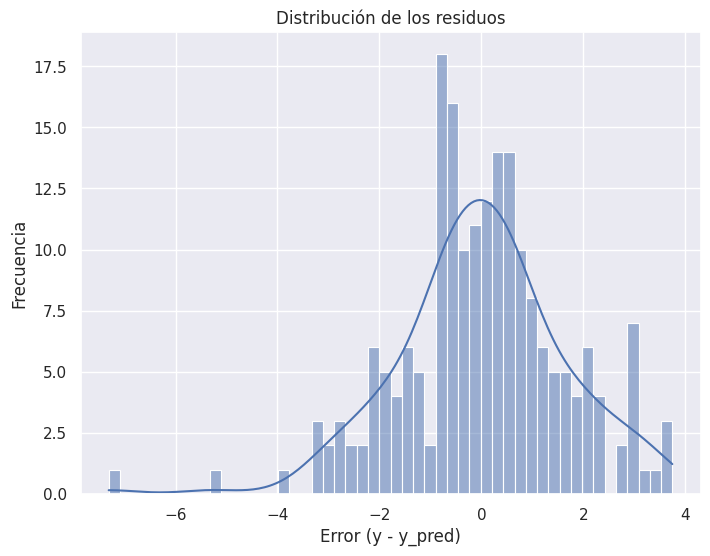

In [149]:
#Normalidad de los residuos

# Realizar predicciones con el modelo
y_pred = model.predict(X_scaled)

# Calcular los residuos del modelo
residuos = y - y_pred

# Histograma de residuos
plt.figure(figsize=(8, 6))
sns.histplot(residuos, bins=50, kde=True)
plt.xlabel("Error (y - y_pred)")
plt.ylabel("Frecuencia")
plt.title("Distribución de los residuos")
plt.show()

### 6.3. Homocedasticidad

1. Grafica los residuos contra los valores predichos.
2. ¿Observas patrones? ¿Los residuos se dispersan aleatoriamente?

No se observan patrones, así mismo, los residuos se dispersan aleatoriamente y existe Homocedasticidad

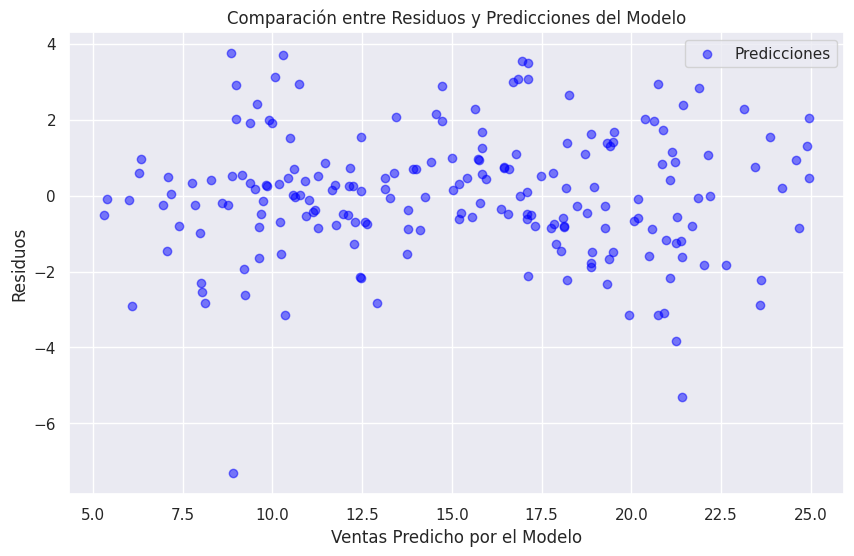


Comparación entre las predicciones y los residuos:
   Residuos  Predicción
0  0.889216   21.210784
1 -0.865819   11.265819
2  1.513286   10.486714
3 -0.806207   17.306207
4  2.267263   15.632737


In [150]:
# Homocedasticidad
# Graficar los residuos frente a las predicciones
plt.figure(figsize=(10, 6))

# Graficar los residuos vs las predicciones
plt.scatter(y_pred, residuos, alpha=0.5, color='blue', label='Predicciones')

# Añadir título y etiquetas
plt.title("Comparación entre Residuos y Predicciones del Modelo")
plt.xlabel("Ventas Predicho por el Modelo")
plt.ylabel("Residuos")

# Añadir leyenda
plt.legend()

# Mostrar la gráfica
plt.show()

# Comparar los primeros valores reales con las predicciones
comparison_residuos = pd.DataFrame({
    'Residuos': residuos.head(),
    'Predicción': y_pred[:5]  # Primeras 5 predicciones
})

print("\nComparación entre las predicciones y los residuos:")
print(comparison_residuos)


### 6.4 Q-Q Plot

1. Graficar el Q-Q Plot
2. Interpreta el gráfico: a) Si los puntos se alinean aproximadamente sobre la línea diagonal, los residuos siguen una distribución normal, b) Desviaciones sistemáticas indican asimetría o colas pesadas.

Los residuos se alinean a la diagonal, por lo cual tenemos una distribución normal, aunque en los extremos observamos algunos puntos alejados a la diagonal lo cual indica la presencia de colas en los extremos

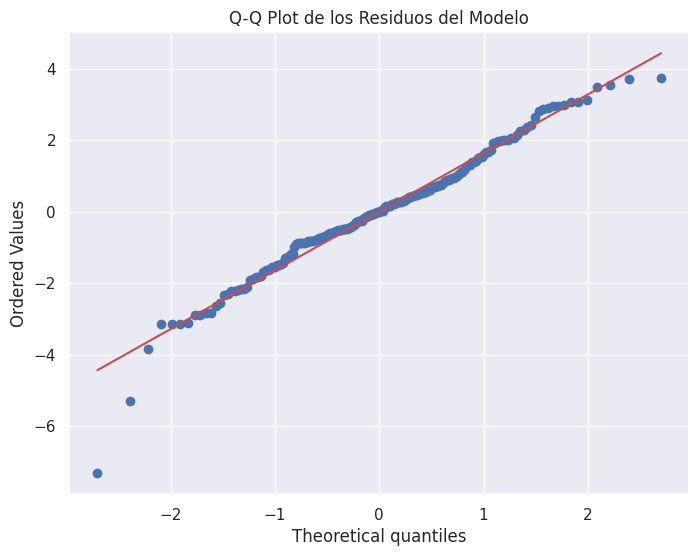

In [151]:
#Q-Q Plot

#  Graficar el Q-Q Plot
plt.figure(figsize=(8, 6))
stats.probplot(residuos, dist="norm", plot=plt)

# Añadir título
plt.title("Q-Q Plot de los Residuos del Modelo")

# Mostrar la gráfica
plt.show()


### 6.5. Evaluación del Modelo

1. Calcula las métricas: a) MSE (error cuadrático medio), b) RMSE (raíz del error cuadrático medio), c) R² (coeficiente de determinación)

2. ¿Qué nos dicen estas métricas sobre el ajuste del modelo?

*  **Error Cuadrático Medio (MSE): 2.7060**  
   El promedio de los errores al cuadrado entre los valores predichos y los valores reales nos emite un valor de **2.7060** indica que el modelo tiene un error moderado.

*  **Raíz del Error Cuadrático Medio (RMSE): 1.6450**  
   La RMSE es una métrica que se encuentra en las mismas unidades que la variable dependiente. Un **RMSE de 1.6450** sugiere que, en promedio, las predicciones del modelo están a aproximadamente **1.6450** de los valores reales. Esto también indica que hay una diferencia moderada entre las predicciones y los valores observados.

*  **Error Absoluto Medio (MAE): 1.2364**  
   Mide el error medio absoluto entre las predicciones y los valores reales. Un valor de **1.2364** muestra que, en promedio, las predicciones del modelo difieren de los valores reales en aproximadamente **1.2364 unidades**, lo que refleja un error moderado. El MAE es menos sensible a outliers que el RMSE.

*  **Coeficiente de Determinación (R²): 0.9026**  
   El R² mide la proporción de la varianza en la variable dependiente que es explicada por el modelo. Un **R² de 0.9026** indica que el modelo explica aproximadamente el **90.26% de la variabilidad** en los datos. Esto sugiere un **ajuste muy bueno**.

In [152]:
#Evaluación del Modelo
# Calcular las métricas del modelo
mse = mean_squared_error(y, y_pred)  # Error cuadrático medio
rmse = np.sqrt(mse)  # Raíz del error cuadrático medio
mae = mean_absolute_error(y, y_pred)  # Error absoluto medio
r2 = r2_score(y, y_pred)  # Coeficiente de determinación R^2

# Mostrar las métricas
print(f"Error Cuadrático Medio (MSE): {mse:.4f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.4f}")
print(f"Error Absoluto Medio (MAE): {mae:.4f}")
print(f"Coeficiente de Determinación (R²): {r2:.4f}")


Error Cuadrático Medio (MSE): 2.7061
Raíz del Error Cuadrático Medio (RMSE): 1.6450
Error Absoluto Medio (MAE): 1.2368
Coeficiente de Determinación (R²): 0.9026


### 6.6. Visualización de Predicciones

1. Crea un gráfico comparando Sales reales vs Sales predichas.

2. Puedes usar plt.scatter(y_true, y_pred) para evaluar visualmente el ajuste.
3.¿Qué observas?¿Qué información puedes obtener de esta gráfica?

Podemos observar que los valores predichos por el modelo son muy cercanos a la línea de perfección, lo cual nos indica que el modelo se genera predicciones precisas y agrupadas, en algunos casos tocan la línea de perfección.  


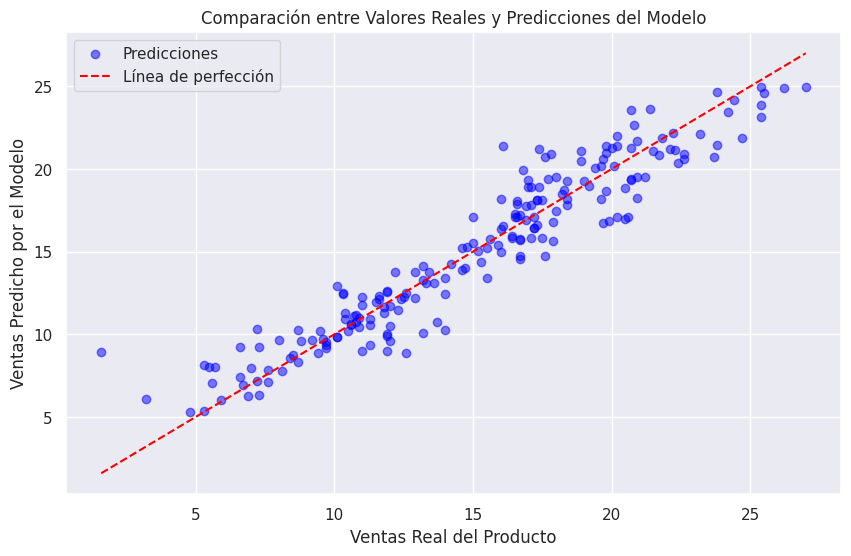


Comparación entre las predicciones y los valores reales:
   Valor Real  Predicción
0        22.1   21.210784
1        10.4   11.265819
2        12.0   10.486714
3        16.5   17.306207
4        17.9   15.632737


In [153]:
# #Visualización de las Predicciones
# Graficar los valores reales frente a las predicciones
plt.figure(figsize=(10, 6))

# Graficar los valores reales vs las predicciones
plt.scatter(y, y_pred, alpha=0.5, color='blue', label='Predicciones')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', label='Línea de perfección')

# Añadir título y etiquetas
plt.title("Comparación entre Valores Reales y Predicciones del Modelo")
plt.xlabel("Ventas Real del Producto")
plt.ylabel("Ventas Predicho por el Modelo")

# Añadir leyenda
plt.legend()

# Mostrar la gráfica
plt.show()

# Comparar los primeros valores reales con las predicciones
comparison = pd.DataFrame({
    'Valor Real': y.head(),
    'Predicción': y_pred[:5]  # Primeras 5 predicciones
})

print("\nComparación entre las predicciones y los valores reales:")
print(comparison)


### 6.7 Verificar el impacto de los atributos en el modelo

1. Ajusta el modelo usando statsmodels en lugar de scikit-learn para obtener los valores p.
2. Interpreta los resultados:

 - Observa los valores P>|t| en la tabla de salida.

 - ¿Qué variables tienen p-value menores a 0.05?

 Las variables TV y Radio tienen valores menores a 0.05

 - ¿Cuál es la conclusión sobre esas variables?

 Las variables TV y Radio son significativas para el modelo predictivo



In [154]:
# Calculo del P-Value para verificar el impacto de los atributos

# Agregar una constante al conjunto de datos X_scaled
X_scaled_with_constant = sm.add_constant(X_scaled)

# Ajustar el modelo de regresión lineal utilizando statsmodels
model_sm = sm.OLS(y, X_scaled_with_constant).fit()

# Imprimir el resumen del modelo
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                     912.7
Date:                Sat, 01 Nov 2025   Prob (F-statistic):          2.39e-100
Time:                        23:24:31   Log-Likelihood:                -383.34
No. Observations:                 200   AIC:                             772.7
Df Residuals:                     197   BIC:                             782.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         15.1305      0.117    129.098      0.0

##7. Conclusiones.

¿Cuál de los tres modelos construidos fue el mejor?
¿Cuál fue el atributo que mas influencia tiene en las ventas?

Solo se construyeron 2 modelos, derivado a que no se identificó `Multicolinealidad`, el segundo modelo al eliminar la variable de `Newspaper` no cambio en nada las predicciones y las evaluaciones en forma general se mantuvo sin cambios significativos. Se concluye que la variable `Newspaper` resulto insignificante para el modelo.